In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
from src.data_generator import parse_actions
from src.settings import output_folder_path

# ---------------------------------------------------
# 2. Calcular la posición seleccionada dentro de las acciones
# ---------------------------------------------------
def selected_block_positions(actions_data):
    positions = []

    for sel_id, coords, actions in actions_data:
        for idx, (act_id, _) in enumerate(actions, start=1):  # índices 1-based
            if act_id == sel_id:
                positions.append(idx)
                break  # solo la primera coincidencia

    freq = Counter(positions)
    max_pos = max(freq) if freq else 0
    result = [(i, freq.get(i, 0)) for i in range(1, max_pos + 1)]
    return result


# ---------------------------------------------------
# 3. Acumular resultados de todos los archivos .out
# ---------------------------------------------------
def accumulate_results_from_folder(folder_path):
    total_counts = defaultdict(int)

    for filename in os.listdir(folder_path):
        if filename.endswith(".out"):
            filepath = os.path.join(folder_path, filename)
            actions_data = parse_actions(filepath)
            result = selected_block_positions(actions_data)

            # Sumar frecuencias simples (NO acumuladas)
            for pos, count in result:
                total_counts[pos] += count

    accumulated_result = sorted(total_counts.items())
    return accumulated_result


# ---------------------------------------------------
# 4. Graficar frecuencia acumulada porcentual
# ---------------------------------------------------
def plot_cumulative_percentage(result):
    positions = np.array([pos for pos, _ in result])
    freqs = np.array([freq for _, freq in result])

    cum_freq = np.cumsum(freqs)
    cum_percent = cum_freq / cum_freq[-1] * 100

    plt.figure(figsize=(8, 5))
    plt.plot(positions, cum_percent)
    plt.xticks(range(0, positions.max() + 10, 10))
    plt.xlabel("Posición")
    plt.ylabel("Frecuencia acumulada (%)")
    plt.title("Frecuencia acumulada porcentual por posición")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def accumulate_results_from_folders(folder_paths):
    """
    Procesa varias carpetas, cada una con archivos .out, y acumula
    las frecuencias de posiciones seleccionadas.

    Args:
        folder_paths (list[str]): Lista de rutas a carpetas con archivos .out

    Returns:
        list[tuple[int, int]]: [(posición, frecuencia total)] ordenadas por posición
    """
    total_counts = defaultdict(int)

    for folder_path in folder_paths:
        folder_path = output_folder_path + folder_path
        if not os.path.isdir(folder_path):
            print(f"⚠️ Carpeta no encontrada: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            if filename.endswith(".out"):
                filepath = os.path.join(folder_path, filename)
                actions_data = parse_actions(filepath)
                result = selected_block_positions(actions_data)

                # Sumar frecuencias simples (no acumuladas)
                for pos, count in result:
                    total_counts[pos] += count

    accumulated_result = sorted(total_counts.items())
    return accumulated_result

In [38]:
folders = ["E4F.out", "E4G.out", "E4H.out", "E4I.out", "E4J.out"]
result = accumulate_results_from_folders(folders)

outputs/E4F.out
outputs/E4G.out
outputs/E4H.out
outputs/E4I.out
outputs/E4J.out


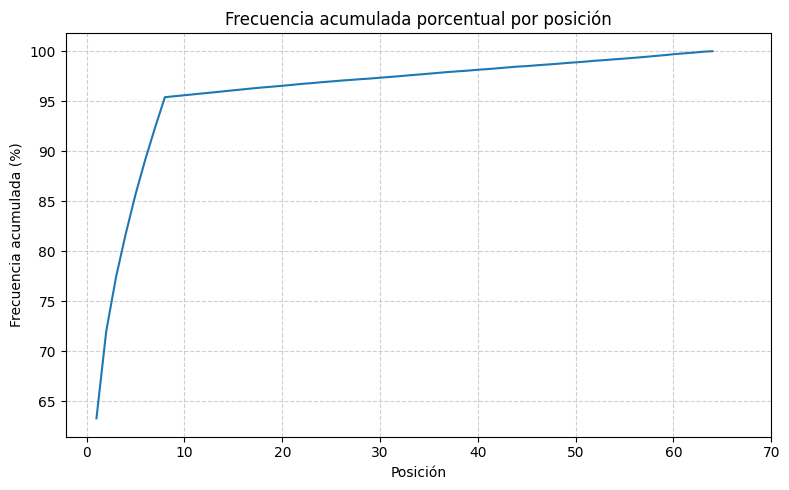

In [39]:
plot_cumulative_percentage(result)

In [45]:
import pandas as pd
import numpy as np

# Suponiendo que 'result' es tu lista de tuplas [(1, 3624), (2, 6472), ...]
df = pd.DataFrame(result, columns=["Posición", "Frecuencia"])

# Total de muestras
total = df["Frecuencia"].sum()

# Frecuencia porcentual (no acumulada)
df["Frecuencia (%)"] = df["Frecuencia"] / total * 100

# Frecuencia acumulada
df["Frecuencia acumulada"] = np.cumsum(df["Frecuencia"])

# Frecuencia acumulada porcentual
df["Frecuencia acumulada (%)"] = df["Frecuencia acumulada"] / total * 100

# Orden final de columnas
df = df[[
    "Posición",
    "Frecuencia (%)",
    "Frecuencia acumulada (%)"
]]

df.head(10)


,Posición,Frecuencia (%),Frecuencia acumulada (%)
0,1,63.305903,63.305903
1,2,8.708515,72.014418
2,3,5.407826,77.422243
3,4,4.350290,81.772534
4,5,3.938838,85.711371
5,6,3.484313,89.195684
6,7,3.197543,92.393226
7,8,3.008252,95.401478
8,9,0.100880,95.502358
9,10,0.096346,95.598703


In [ ]:
# Crear una columna de grupo según el rango de posición
def clasificar_grupo(pos):
    if pos == 1:
        return "Grupo 1 (posición 1)"
    elif 2 <= pos <= 8:
        return "Grupo 2 (pos 2–8)"
    else:
        return "Grupo 3 (pos ≥9)"

# Agregar la columna de grupo
df["Grupo"] = df["Posición"].apply(clasificar_grupo)

# Agrupar y sumar los porcentajes
grupos = (
    df.groupby("Grupo", as_index=False)
      .agg({"Frecuencia (%)": "sum"})
      .sort_values("Grupo")
)

# Renombrar columna para claridad
grupos.rename(columns={"Frecuencia (%)": "Frecuencia porcentual total (%)"}, inplace=True)

grupos

,Grupo,Frecuencia porcentual total (%)
0,Grupo 1 (posición 1),63.305903
1,Grupo 2 (pos 2–8),32.095575
2,Grupo 3 (pos ≥9),4.598522
